In [1]:
import pandas as pd
import numpy as np
import os

# 1. 파일 경로 설정
input_path = r"C:\Users\hahas\death_counts_to_raw_expanded_종합.xlsx"
save_path = r"C:\Users\hahas\리스크_분류_가중치_결과.xlsx"

# 2. 데이터 로드
try:
    df_raw = pd.read_excel(input_path)
    print("✨ 원본 데이터를 성공적으로 로드했습니다.")
except Exception as e:
    print(f"⚠️ 에러 발생: {e}")
    exit()

# 3. Wide to Long (데이터 재구조화)
age_cols = ['10대', '20-29세', '30-39세', '40-49세', '50-59세', '60-69세']
df_long = df_raw.melt(
    id_vars=['사고 및 질환 항목', '성별'],
    value_vars=age_cols,
    var_name='연령대',
    value_name='건수'
)

# 4. 5대 분류 매핑 함수 정의
def classify_risk(row):
    item = row['사고 및 질환 항목']
    
    # [면책]
    if item in ['고의적 자해(자살)', '정신활성 물질 사용에 의한 정신 및 행동 장애']:
        return '면책'
    
    # [상해 관련 항목]
    injuries = ['운수 사고 (교통사고)', '불의의 물에 빠짐 (익사)', '추락 (미끄러짐)', 
                '유독성 물질에 의한 불의의 중독 및 노출', '가해 (타살)', '연기, 불 및 불꽃에 노출']
    
    # [3대 비급여] Proxy 설정: 
    # 도수치료/주사/MRI는 주로 '추락'이나 '근골격계 관련 만성질환' 리스크와 동조함
    if item == '추락 (미끄러짐)':
        return '3대 비급여' # 추락은 치료비(3대비급여) 발생 확률이 매우 높은 항목
    
    if item in injuries:
        return '상해통원'
    
    # [질병 관련 항목]
    return '질병통원'

# 분류 적용
df_long['대분류'] = df_long.apply(classify_risk, axis=1)

# 5. [중요] 사망 및 장해 리스크 복제
# 모든 사망 사고는 '사망 및 장해' 담보의 가중치 원천이 되므로 데이터를 복제하여 추가합니다.
df_death_risk = df_long[df_long['대분류'] != '면책'].copy()
df_death_risk['대분류'] = '사망 및 장해'

# 최종 데이터 병합
df_final_pool = pd.concat([df_long, df_death_risk], ignore_index=True)

# 6. 연령대/성별/분류별 가중치 집계
df_summary = df_final_pool.groupby(['연령대', '성별', '대분류'])['건수'].sum().reset_index()

# 각 연령/성별 그룹 내에서의 비율(가중치) 계산
total_by_group = df_summary.groupby(['연령대', '성별'])['건수'].transform('sum')
df_summary['리스크_가중치'] = (df_summary['건수'] / total_by_group).round(4)

# 7. 엑셀 저장
try:
    with pd.ExcelWriter(save_path) as writer:
        df_summary.to_excel(writer, sheet_name='가중치_요약', index=False)
        df_final_pool.to_excel(writer, sheet_name='전체_매핑_데이터', index=False)
    print(f"💾 가중치 분석 결과 저장 완료: {save_path}")
except PermissionError:
    print("⚠️ 엑셀 파일이 열려 있습니다. 파일을 닫고 다시 실행해주세요.")


✨ 원본 데이터를 성공적으로 로드했습니다.
💾 가중치 분석 결과 저장 완료: C:\Users\hahas\리스크_분류_가중치_결과.xlsx


In [2]:
import pdfplumber
import pandas as pd
import numpy as np
import re
import os
from datetime import datetime

# 💡 1. 판다스 경고 방지 및 옵션 설정
pd.set_option('future.no_silent_downcasting', True)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# [환율 설정]
EXCHANGE_RATE = 9.0
USD_RATE = 1350.0

BASE_DIR = os.getcwd()

# ==========================================
# 1. 국내 상품: 보장명 추출 및 강제 주입 엔진
# ==========================================
def extract_base_data_from_pdf(file_path, plan_name, base_age=40, gender=1):
    if not os.path.exists(file_path):
        print(f"⚠️ 파일을 찾을 수 없습니다: {os.path.basename(file_path)}")
        return None

    ml_row = {
        '상품플랜': plan_name, 
        '기준나이': base_age, 
        '성별': '남성' if gender == 1 else '여성'
    }
    
    # DB 국내여행(일반)은 기준나이 35세 특이케이스 유지
    if 'DB_국내여행' in plan_name and '실손' not in plan_name:
        ml_row['기준나이'] = 35

    try:
        # 💡 [데이터 복구] 각 상품별 정확한 보장금액 강제 주입
        
        # --- (1) KB 손해보험 ---
        if 'KB_국내' in plan_name: 
            ml_row['기준보험료'] = 7000
            ml_row['사망및장해_상해사망'] = 200000000
            ml_row['사망및장해_상해후유장해'] = 200000000
            ml_row['사망및장해_질병사망및80%이상후유장해'] = 50000000
            ml_row['일상손해_휴대품손해(분실제외)'] = 200000
            ml_row['일상손해_배상책임'] = 30000000

        # --- (2) 삼성화재 국내여행 (이미지 반영) ---
        if '삼성_국내여행' in plan_name:
            ml_row['기준보험료'] = 3930 
            ml_row['사망및장해_상해사망'] = 100000000
            ml_row['사망및장해_상해후유장해'] = 100000000
            ml_row['사망및장해_질병사망및80%이상후유장해'] = 10000000
            ml_row['일상손해_배상책임'] = 10000000
            ml_row['일상손해_휴대품손해(분실제외)'] = 1000000

        # --- (3) 현대해상 유학생 (이미지 반영) ---
        if '현대_유학생' in plan_name:
            ml_row['기준보험료'] = 15500
            ml_row['사망및장해_상해사망'] = 10000000
            ml_row['사망및장해_상해후유장해'] = 10000000
            ml_row['사망및장해_질병사망및80%이상후유장해'] = 10000000
            ml_row['특수리스크_구원자비용'] = 10000000
            ml_row['특수리스크_항공기지연비용'] = 100000

        # --- (4) DB손해보험 국내여행 (일반형 복구) ---
        if 'DB_국내여행' in plan_name and '실손' not in plan_name:
            ml_row['기준보험료'] = 11330
            ml_row['사망및장해_상해사망'] = 50000000
            ml_row['사망및장해_상해후유장해'] = 50000000
            ml_row['사망및장해_질병사망및80%이상후유장해'] = 5000000
            ml_row['일상손해_배상책임'] = 5000000
            ml_row['일상손해_휴대품손해(분실제외)'] = 200000
            # 기본 상해/질병 입원비 주입
            ml_row['입원의료비_상해입원'] = 5000000
            ml_row['입원의료비_질병입원'] = 5000000

        # --- (5) DB손해보험 국내여행 (실손형) ---
        if 'DB_국내실손' in plan_name: 
            ml_row['기준보험료'] = 16040 if gender == 1 else 18940
            ml_row['입원의료비_상해질병통합'] = 50000000
            ml_row['통원의료비_상해외래'] = 250000
            ml_row['통원의료비_질병외래'] = 250000
            ml_row['통원의료비_상해처방조제'] = 50000
            ml_row['통원의료비_질병처방조제'] = 50000
            ml_row['3대비급여_도수·체외충격파·증식치료'] = 3500000
            ml_row['3대비급여_비급여주사료'] = 2500000
            ml_row['3대비급여_MRI/MRA'] = 3000000

        # --- (6) 삼성화재 글로벌실손 (유학생) ---
        if '삼성_글로벌실손' in plan_name:
            ml_row['기준보험료'] = 478700 / 12 if gender == 1 else 520300 / 12
            ml_row['특수리스크_해외상해의료비(USD)'] = 15000 * USD_RATE
            ml_row['특수리스크_해외질병의료비(USD)'] = 10000 * USD_RATE
            ml_row['입원의료비_상해급여(국내)'] = 10000000
            ml_row['입원의료비_질병급여(국내)'] = 10000000
            ml_row['3대비급여_통합한도'] = 9000000

        return ml_row
    except Exception as e:
        print(f"Error parsing {plan_name}: {e}")
        return None

# ==========================================
# 2. 계리적 시뮬레이션 및 데이터 병합 (기존 로직 유지)
# ==========================================
def calculate_projected_premium(plan_name, base_p, target_age, base_age, gender):
    if base_p == 0: return 0
    diff = target_age - base_age
    projected_p = base_p
    if 'KB_국내' in plan_name: projected_p = base_p * ((1 + 0.0112) ** diff)
    elif '삼성_국내여행' in plan_name:
        rate = 1.0965 if target_age >= base_age else (1.0965 if gender == '남성' else 1.467)
        projected_p = base_p * (rate ** (diff/10)) if target_age >= base_age else base_p / (rate ** (-diff/10))
    elif 'DB_국내' in plan_name: 
        projected_p = base_p * ((1 + (0.0064 if gender == '남성' else 0.056)) ** diff)
    elif '현대_유학생' in plan_name: 
        projected_p = base_p * (1.25 ** (diff/10)) * (1.15 if gender == '여성' and target_age >= base_age else 1)
    elif '삼성_글로벌' in plan_name: 
        projected_p = base_p * ((1 + (0.012 if gender == '남성' else 0.022)) ** diff)
    
    if '글로벌' in plan_name: projected_p = projected_p
    elif 'KB_국내' in plan_name: projected_p *= 3.0
    elif '삼성_국내여행' in plan_name: projected_p *= (30.0 / 7.0)
    return int(round(projected_p, -1))

# ==========================================
# 3. 메인 실행 (전체 상품군 가동)
# ==========================================
pdf_configs = [
    {"path": "삼성화재_국내여행보험_상품요약서.pdf", "plan": "삼성_국내여행"},
    {"path": "삼성화재_글로벌케어_실손의료보험_상품요약서.pdf", "plan": "삼성_글로벌실손"},
    {"path": "현대해상_외국인유학생보험_상품요약서.pdf", "plan": "현대_유학생"},
    {"path": "DB손해보험_프로미다이렉트_국내여행보험_상품요약서.pdf", "plan": "DB_국내여행"},
    {"path": "DB손해보험_프로미다이렉트_국내여행실손의료비보험_상품요약서.pdf", "plan": "DB_국내실손"},
    {"path": "KB손해보험_국내여행보험_상품요약서.pdf", "plan": "KB_국내여행"}
]

all_data = []
print("▶️ 데이터 통합 복구 및 시뮬레이션 시작...")

for gen in [1, 0]:
    for cfg in pdf_configs:
        d = extract_base_data_from_pdf(os.path.join(BASE_DIR, cfg['path']), cfg['plan'], gender=gen)
        if d:
            d['국가'] = '한국(KRW)'
            d['orig'] = cfg['plan']
            all_data.append(d)

rows = []
for base in all_data:
    orig = base.pop('orig', base['상품플랜'])
    for age in [10, 20, 30, 40, 50, 60, 70]:
        r = base.copy()
        r['가입나이'] = age
        r['최종보험료'] = calculate_projected_premium(orig, base.get('기준보험료', 0), age, base.get('기준나이', 40), base['성별'])
        rows.append(r)

master_df = pd.DataFrame(rows).drop(columns=['기준나이', '기준보험료'], errors='ignore')

# 💡 중복 컬럼 통합 및 결측치 해결 (T.groupby 활용)
master_df = master_df.T.groupby(level=0).max().T
master_df = master_df.fillna(0).infer_objects(copy=False)

# 💡 불필요 컬럼 삭제
forbidden = ['선택계약', '기본계약', '기본형', '특약형', '4세대실손']
master_df.drop(columns=[c for c in master_df.columns if any(k in c for k in forbidden)], inplace=True, errors='ignore')

# 컬럼 정렬
meta = ['국가', '상품플랜', '가입나이', '성별', '최종보험료']
features = sorted([c for c in master_df.columns if c not in meta])
master_df = master_df[meta + features]

save_path = os.path.join(BASE_DIR, "통합_보험데이터_최종_1개월_월환산완료.csv")
master_df.to_csv(save_path, index=False, encoding='utf-8-sig')

print(f"\n✨ 작업 완료! DB 국내여행/실손 데이터를 포함한 모든 보장 내역이 복구되었습니다.")
print(f"💾 결과 저장: {save_path}")


▶️ 데이터 통합 복구 및 시뮬레이션 시작...

✨ 작업 완료! DB 국내여행/실손 데이터를 포함한 모든 보장 내역이 복구되었습니다.
💾 결과 저장: C:\Users\hahas\통합_보험데이터_최종_1개월_월환산완료.csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import platform

# 💡 1. 한글 폰트 완벽 설정 (Windows/Mac 자동 대응)
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic') # 윈도우: 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')   # 맥: 애플 고딕
else:
    plt.rc('font', family='NanumGothic')   # 리눅스: 나눔 고딕
plt.rc('axes', unicode_minus=False)        # 마이너스 기호 깨짐 방지

# 💡 금액을 '억', '만' 단위로 예쁘게 변환하는 함수
def format_korean_money(val):
    if val == 0:
        return ""
    elif val >= 100000000:
        return f"{val/100000000:.1f}억"
    elif val >= 10000:
        return f"{val/10000:,.0f}만"
    else:
        return f"{val:,.0f}"

# 2. 데이터 로드 및 40세 남성 필터링
df = pd.read_csv('통합_보험데이터_최종_1개월_월환산완료.csv', encoding='utf-8-sig')

# 데이터에 40세 남성이 있는지 확인 후 필터링
target_age = 40 if 40 in df['가입나이'].unique() else df['가입나이'].unique()[0]
target_gender = '남성' if '남성' in df['성별'].unique() else df['성별'].unique()[0]
df_sub = df[(df['가입나이'] == target_age) & (df['성별'] == target_gender)].copy()

# 3. 대분류 카테고리 정의 및 병합
categories = ['사망및장해', '입원의료비', '통원의료비', '3대비급여', '일상손해']

for cat in categories:
    cols = [c for c in df.columns if cat in c]
    df_sub[cat] = df_sub[cols].sum(axis=1)

# 가성비 계산
df_sub['총보장금액'] = df_sub[categories].sum(axis=1)
df_sub['가성비지수'] = df_sub['총보장금액'] / df_sub['최종보험료']

# =========================================================
# 📈 차트 1. 보장 대분류 누적 막대 그래프 (금액 라벨 포함)
# =========================================================
plot_data = df_sub[['상품플랜'] + categories].set_index('상품플랜')
ax1 = plot_data.plot(kind='barh', stacked=True, figsize=(14, 8), colormap='viridis', width=0.7)

# 막대 안에 '억/만' 단위 텍스트 삽입
for idx, plan in enumerate(plot_data.index):
    cum_sum = 0
    for col in categories:
        val = plot_data.loc[plan, col]
        if val > 0:
            ax1.text(cum_sum + val/2, idx, format_korean_money(val), 
                     va='center', ha='center', color='white', fontsize=10, fontweight='bold')
        cum_sum += val

plt.title(f'보험사별 대분류 보장 금액 비교 ({target_age}세 {target_gender} 기준)', fontsize=16, pad=15)
plt.xlabel('보장 금액 합계 (원)', fontsize=12)
plt.ylabel('보험 상품명', fontsize=12)
plt.legend(title='보장 대분류', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('1_coverage_breakdown.png', dpi=300)
plt.close()

# =========================================================
# 📈 차트 2. 가격 대비 보장 효율 (가성비 순위)
# =========================================================
eff_sorted = df_sub.sort_values('가성비지수', ascending=False)

plt.figure(figsize=(12, 6))
ax2 = sns.barplot(data=eff_sorted, x='가성비지수', y='상품플랜', hue='상품플랜', palette='magma', legend=False)

# 막대 끝에 가성비 수치 표시
for i, p in enumerate(ax2.patches):
    ax2.annotate(f'{p.get_width():,.1f}', (p.get_width(), p.get_y() + p.get_height()/2.),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=11, fontweight='bold')

plt.title('보험료 1원당 총 보장금액 (가성비 지수)', fontsize=16, pad=15)
plt.xlabel('가성비 지수 (총 보장금액 / 월 보험료)', fontsize=12)
plt.ylabel('보험 상품명', fontsize=12)
plt.xlim(0, eff_sorted['가성비지수'].max() * 1.15) # 글씨 여백 확보
plt.tight_layout()
plt.savefig('2_efficiency_rank.png', dpi=300)
plt.close()

# =========================================================
# 📈 차트 3. 보장 밸런스 레이더 차트 (정규화)
# =========================================================
radar_data = df_sub[categories].copy()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min() + 1e-9)

num_vars = len(categories)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax3 = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for i in range(len(df_sub)):
    plan_name = df_sub['상품플랜'].iloc[i]
    values = radar_norm.iloc[i].tolist()
    values += values[:1]
    
    line, = ax3.plot(angles, values, label=plan_name, linewidth=2.5)
    ax3.fill(angles, values, alpha=0.08)
    
    # 주요 포인트에 실제 금액(억/만) 표시
    raw_vals = df_sub[categories].iloc[i].tolist()
    for angle, r_val, n_val in zip(angles[:-1], raw_vals, values[:-1]):
        if n_val > 0.8: # 가장 두드러진 강점(80% 이상)에만 라벨 표시
             ax3.text(angle, n_val, format_korean_money(r_val), 
                      color=line.get_color(), fontsize=10, fontweight='bold')

ax3.set_theta_offset(np.pi / 2)
ax3.set_theta_direction(-1)
ax3.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=11)
plt.title('보험사별 보장 밸런스 비교 (강점 분석)', y=1.08, fontsize=15)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('3_radar_balance.png', dpi=300)
plt.close()

# =========================================================
# 📈 차트 4. 보험료 vs 총 보장금액 (산점도)
# =========================================================
plt.figure(figsize=(11, 7))
sns.scatterplot(data=df_sub, x='최종보험료', y='총보장금액', hue='상품플랜', s=400, alpha=0.8)

# 점수 옆에 상품명 및 총 보장액(억/만) 표시
for i in range(len(df_sub)):
    plan = df_sub['상품플랜'].iloc[i]
    prem = df_sub['최종보험료'].iloc[i]
    cov = df_sub['총보장금액'].iloc[i]
    plt.text(prem + 200, cov, f"{plan}\n({format_korean_money(cov)})", 
             fontsize=10, verticalalignment='center')

plt.title('월 보험료 vs 총 보장금액 분포', fontsize=16, pad=15)
plt.xlabel('월 최종 보험료 (원)', fontsize=12)
plt.ylabel('총 보장 금액 (원)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('4_premium_vs_coverage.png', dpi=300)
plt.close()

print("\n✨ 완벽한 한글 폰트와 '억/만' 단위가 적용된 차트 4장이 생성되었습니다.")


✨ 완벽한 한글 폰트와 '억/만' 단위가 적용된 차트 4장이 생성되었습니다.


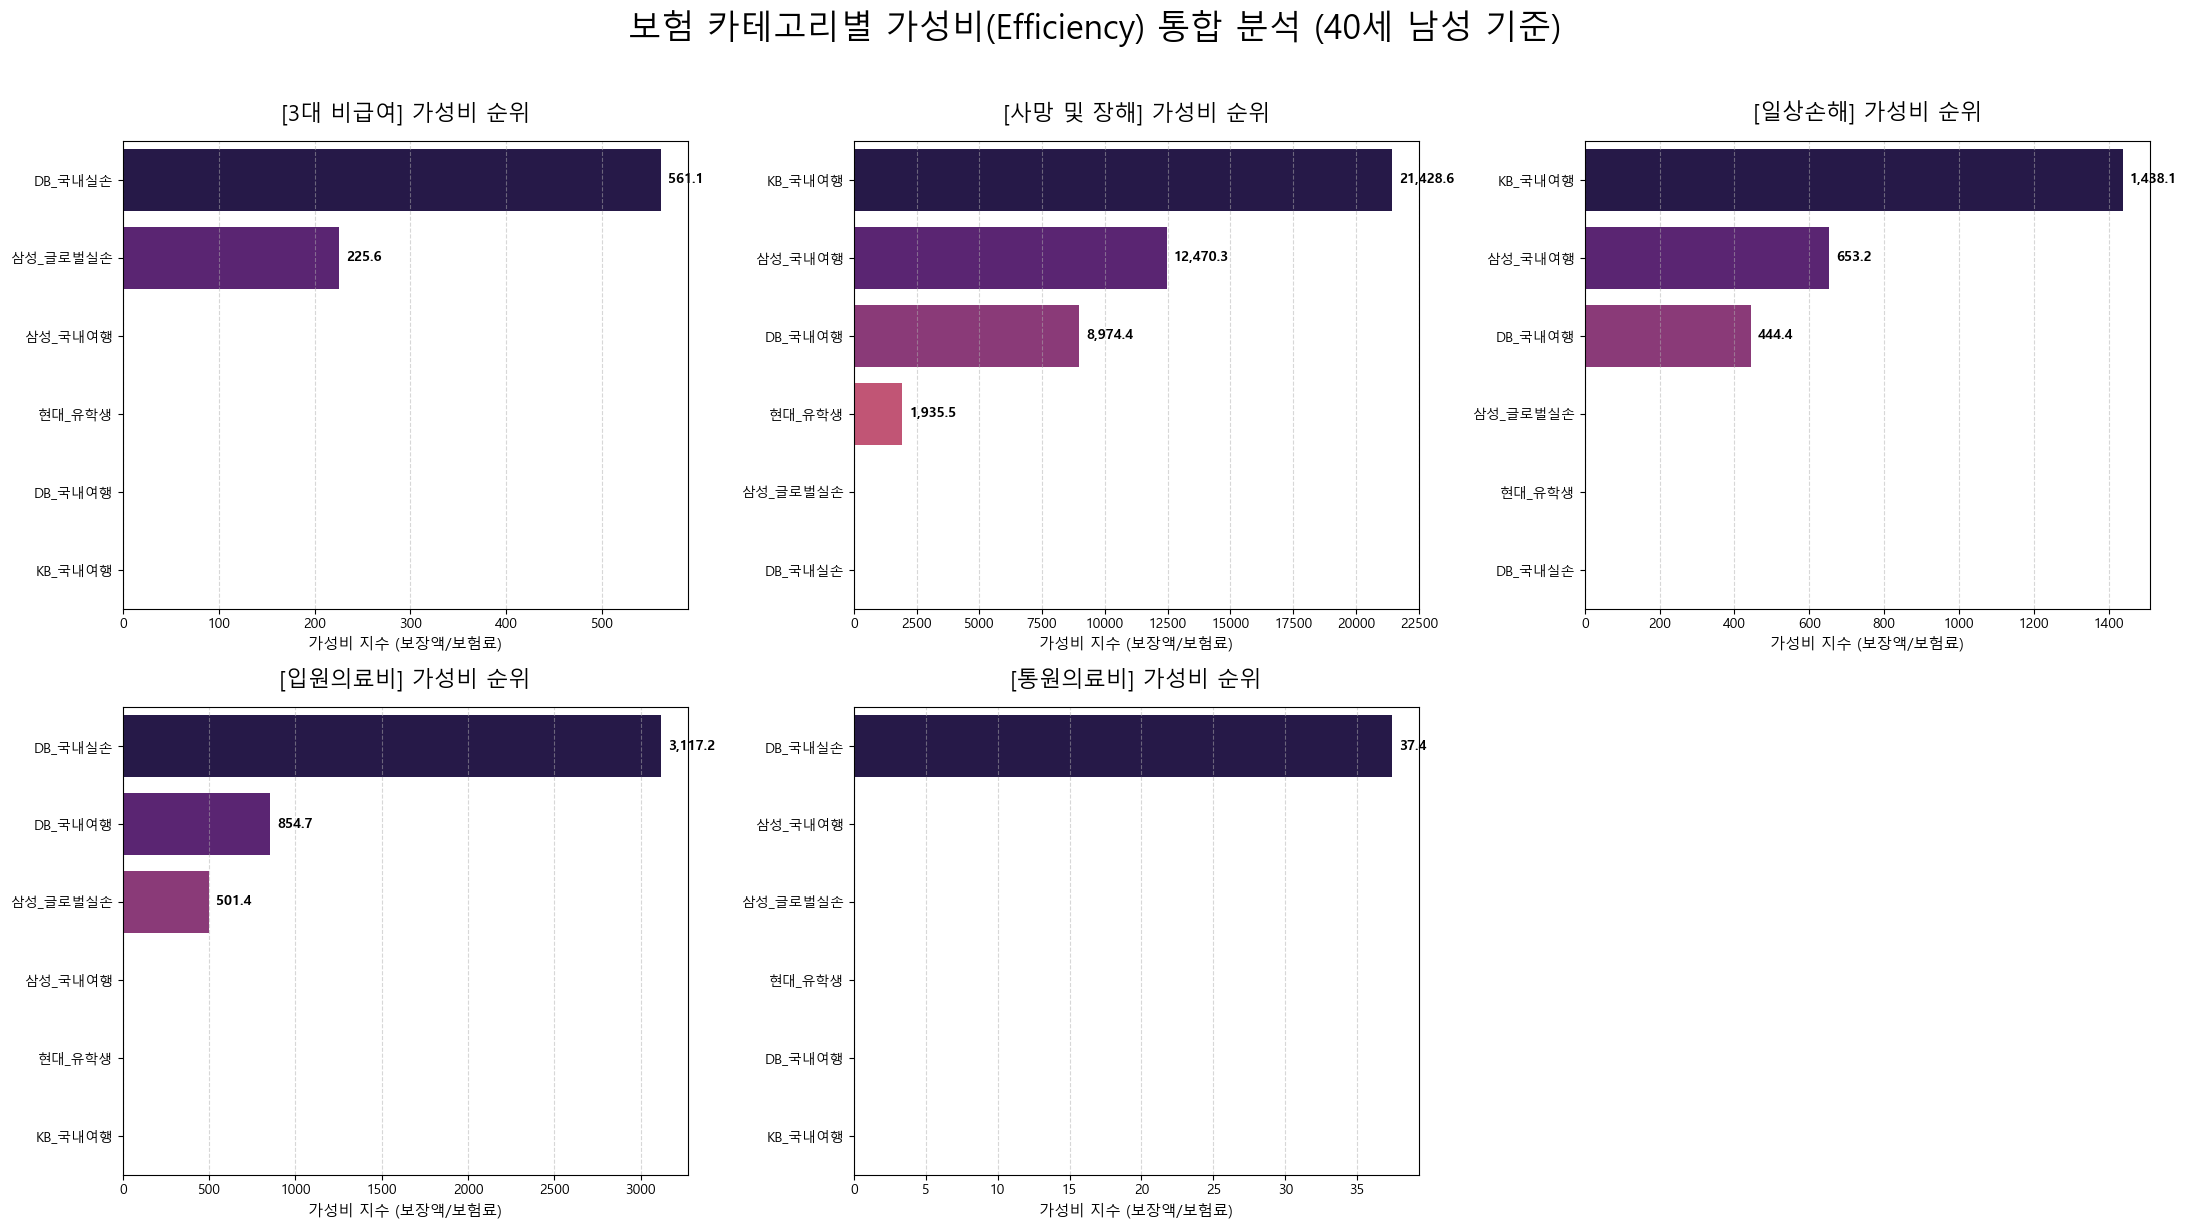

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

# 2. 데이터 로드
df = pd.read_csv('통합_보험데이터_최종_1개월_월환산완료.csv', encoding='utf-8-sig')

# 분석 타겟 설정 (40세 남성 기준)
target_age = 40
target_gender = '남성'
df_sub = df[(df['가입나이'] == target_age) & (df['성별'] == target_gender)].copy()

# 3. 분석할 5대 카테고리 정의
analysis_cats = {
    '3대 비급여': '3대비급여',
    '사망 및 장해': '사망및장해',
    '일상손해': '일상손해',
    '입원의료비': '입원의료비',
    '통원의료비': '통원의료비'
}

# 4. 시각화 (2행 3열 레이아웃)
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()

for i, (label, keyword) in enumerate(analysis_cats.items()):
    # 해당 카테고리 키워드가 포함된 컬럼 합산
    cols = [c for c in df.columns if keyword in c]
    df_sub[f'{label}_합계'] = df_sub[cols].sum(axis=1)
    
    # 가성비 지수 계산 (보장액 / 보험료)
    df_sub[f'{label}_지수'] = df_sub[f'{label}_합계'] / df_sub['최종보험료']
    
    # 데이터 정렬
    plot_data = df_sub.sort_values(f'{label}_지수', ascending=False)
    
    # 💡 수정 포인트: hue='상품플랜' 할당 및 legend=False 추가하여 경고 해결
    sns.barplot(
        data=plot_data, 
        x=f'{label}_지수', 
        y='상품플랜', 
        hue='상품플랜', 
        ax=axes[i], 
        palette='magma', 
        legend=False
    )
    
    # 막대 끝에 수치 표시
    for p in axes[i].patches:
        val = p.get_width()
        if val > 0:
            axes[i].annotate(f'{val:,.1f}', (val, p.get_y() + p.get_height()/2.),
                             ha='left', va='center', xytext=(5, 0), textcoords='offset points', 
                             fontsize=10, fontweight='bold')
    
    axes[i].set_title(f'[{label}] 가성비 순위', fontsize=16, pad=15)
    axes[i].set_xlabel('가성비 지수 (보장액/보험료)', fontsize=11)
    axes[i].set_ylabel('')
    axes[i].grid(axis='x', linestyle='--', alpha=0.5)

# 남는 6번째 차트 공간 제거
if len(analysis_cats) < len(axes):
    fig.delaxes(axes[5])

plt.suptitle(f'보험 카테고리별 가성비(Efficiency) 통합 분석 ({target_age}세 {target_gender} 기준)', fontsize=24, y=1.02)
plt.tight_layout()

# 이미지 저장
plt.savefig('fixed_category_efficiency.png', dpi=300, bbox_inches='tight')
plt.show()